In [1]:
import gym
import d4rl 
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display  import clear_output

/home/nazim/.local/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:9: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn
/home/nazim/.local/lib/python3.10/site-packages/mujoco_py/builder.py:9: DeprecationWarning: The distutils.sysconfig module is deprecated, use sysconfig instead
  from distutils.sysconfig import customize_compiler
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead
No module named 'flow'
No module named 'carla'
pybullet build time: Jan 29 2025 23:16:28


In [11]:
gym.envs.registry

├──CartPole: [ v0, v1 ]
├──MountainCar: [ v0 ]
├──MountainCarContinuous: [ v0 ]
├──Pendulum: [ v1 ]
├──Acrobot: [ v1 ]
├──LunarLander: [ v2 ]
├──LunarLanderContinuous: [ v2 ]
├──BipedalWalker: [ v3 ]
├──BipedalWalkerHardcore: [ v3 ]
├──CarRacing: [ v1 ]
├──Blackjack: [ v1 ]
├──FrozenLake: [ v1 ]
├──FrozenLake8x8: [ v1 ]
├──CliffWalking: [ v0 ]
├──Taxi: [ v3 ]
├──Reacher: [ v2 ]
├──Pusher: [ v2 ]
├──InvertedPendulum: [ v2 ]
├──InvertedDoublePendulum: [ v2 ]
├──HalfCheetah: [ v2, v3 ]
├──Hopper: [ v2, v3 ]
├──Swimmer: [ v2, v3 ]
├──Walker2d: [ v2, v3 ]
├──Ant: [ v2, v3 ]
├──Humanoid: [ v2, v3 ]
├──HumanoidStandup: [ v2 ]
├──antmaze-umaze: [ v0, v1, v2 ]
├──antmaze-umaze-diverse: [ v0, v1, v2 ]
├──antmaze-medium-play: [ v0, v1, v2 ]
├──antmaze-medium-diverse: [ v0, v1, v2 ]
├──antmaze-large-diverse: [ v0, v1, v2 ]
├──antmaze-large-play: [ v0, v1, v2 ]
├──antmaze-eval-umaze: [ v0 ]
├──antmaze-eval-umaze-diverse: [ v0 ]
├──antmaze-eval-medium-play: [ v0 ]
├──antmaze-eval-medium-diverse: [ v

In [33]:
from gym.vector import SyncVectorEnv

def make_env():
    def _init():
        env = gym.make("Ant-v2")
        return env
    return _init

num_envs = 128
envs = SyncVectorEnv([make_env() for _ in range(num_envs)])


/home/nazim/.local/lib/python3.10/site-packages/gym/envs/registration.py:505: UserWarning: WARN: The environment Ant-v2 is out of date. You should consider upgrading to version `v3` with the environment ID `Ant-v3`.
  logger.warn(


In [63]:
env = gym.make('antmaze-large-diverse-v2')
print(env.observation_space.shape) 

Target Goal:  (32.189210320523614, 24.891838886136043)
(29,)


/home/nazim/.local/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


In [34]:
state = envs.reset()

In [35]:
state.shape

(128, 111)

In [15]:
for _ in tqdm(range(10000)):

    a = env.action_space.sample()
    state, reward, done, info = env.step(a)
    
    # clear_output(True)
    # img = env.render(mode='rgb_array', width=200, height=200)
    # plt.imshow(img)
    # plt.show()

100%|██████████| 10000/10000 [00:02<00:00, 4519.38it/s]


In [61]:
env.unwrapped.get_starting_boundary

AttributeError: 'AntMazeEnv' object has no attribute 'get_starting_boundary'

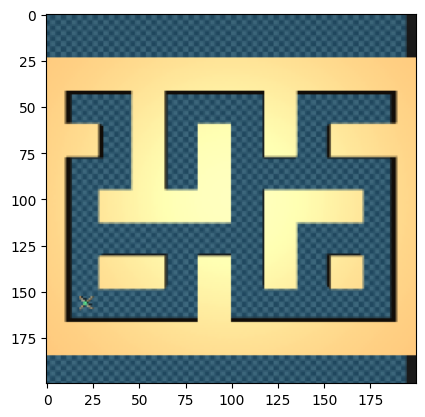

In [65]:
i = 14

img = env.render(mode='rgb_array', width=200, height=200)

env.viewer.cam.lookat[0] = 18
env.viewer.cam.lookat[1] = 13
env.viewer.cam.distance = 55
env.viewer.cam.elevation = -90

img = env.render(mode='rgb_array', width=200, height=200)


plt.imshow(img)

In [128]:
envs.envs[0].render

<bound method Wrapper.render of <TimeLimit<OrderEnforcingNormalized: <AntMazeEnv instance>>>>